# Projeto Previsão ENADE

Este notebook apresenta o desenvolvimento de um modelo de **regressão linear** para prever o desempenho de estudantes em provas, utilizando informações socioeducacionais e acadêmicas.

O objetivo principal é responder à seguinte pergunta:

> **“Quais características dos estudantes influenciam seu desempenho acadêmico e como podemos prever suas notas com base nesses fatores?”**

---

## Objetivos do Projeto

Utilizaremos o dataset **Student Performance**, que contém variáveis como:

- `sex` – sexo do estudante  
- `race/ethnicity` – grupo étnico  
- `parental_level_of_education` – nível educacional dos pais  
- `lunch` – tipo de almoço (proxy socioeconômica)  
- `test_preparation_course` – participação em curso preparatório  
- `reading_score` – nota de leitura  
- `writing_score` – nota de escrita  

O projeto segue as etapas:

1. **Exploração e Entendimento dos Dados**  
2. **Pré-processamento:**  
   - Tratamento de variáveis categóricas  
   - Normalização de variáveis numéricas  
   - Organização das colunas do modelo  
3. **Construção do modelo de Regressão Linear**  
4. **Avaliação do Modelo com Métricas:**  
   - MAE  
   - MSE  
   - RMSE  
   - R²  
5. **Análise dos Resíduos**  
6. **Aplicação de Técnicas de Regularização:** Ridge e Lasso  
7. **Implementação da classe final de predição (`ModeloRegressaoAluno`)**

---

## Resultado Final

Ao final deste notebook, teremos uma classe capaz de:

- Receber os dados de um aluno (novas observações)  
- Aplicar o mesmo pipeline usado no treinamento (OneHotEncoding + normalização)  
- Gerar uma previsão de nota com o modelo treinado  




Importação das bibliotecas

In [ ]:
#importar arquivo e manipulação de dados
from google.colab import files
import pandas as pd
import numpy as np
#plotar grafico
import matplotlib.pyplot as plt
import seaborn as sns
#pre-processamento e preparação dos dados
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
#modelo
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
#metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#exportar modelos, encoders e scaler
import joblib

In [ ]:
plt.style.use("default")
sns.set(font_scale=1.1)

### Carregar Dataset

In [ ]:
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [ ]:
df_raw = pd.read_csv("/content/StudentsPerformance.csv")

In [ ]:
df_raw.head()

,sex,race/ethnicity,parental level of education,lunch,test preparation course,enade score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df_raw.columns = df_raw.columns.str.replace(" ", "_")

In [ ]:
df_raw.head()

,sex,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,enade_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Análise Descritiva Simples

In [ ]:
df = df_raw.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sex                          1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   enade_score                  1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
numericas = list(df.select_dtypes(include=['int64']).columns)

df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
enade_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


Matriz de correlação

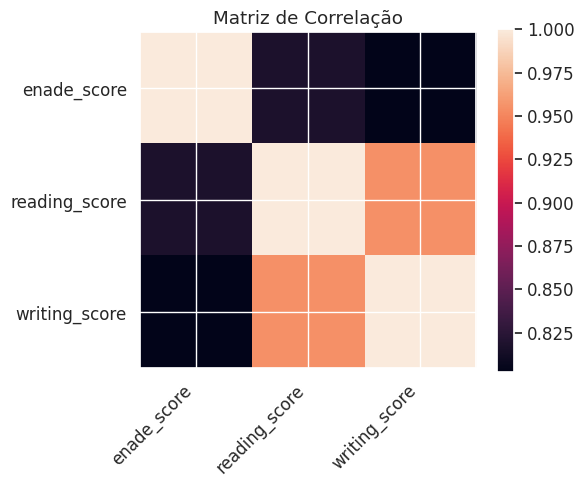

In [ ]:
corr = df[numericas].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de Correlação")
plt.tight_layout()

plt.show()

### Preparação dos Dados

In [ ]:
df2 = df.copy()

Identificação de Outliers

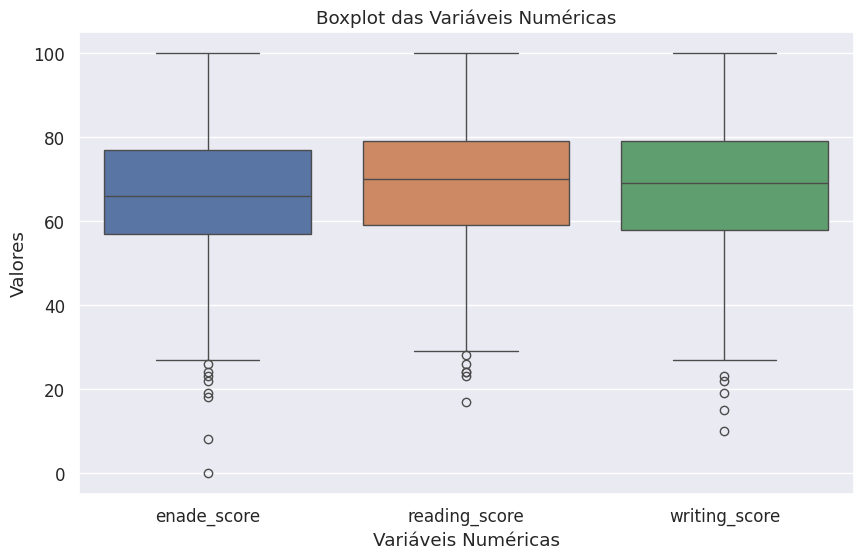

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numericas])

plt.xlabel('Variáveis Numéricas')
plt.ylabel('Valores')
plt.title('Boxplot das Variáveis Numéricas')

plt.show()

In [ ]:
def detectar_outliers_iqr(serie, fator=1.5):
    """
    Retorna limites inferior e superior de outliers usando o método IQR.
    """
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - fator * IQR
    limite_superior = Q3 + fator * IQR
    return limite_inferior, limite_superior

In [ ]:
for col in numericas:
    limite_inferior, limite_superior = detectar_outliers_iqr(df[col])
    qtd = df[(df[col] < limite_inferior) | (df[col] > limite_superior)].shape[0]

    print(f"Coluna: {col} - qtd de outliers: {qtd} - limite inferior: {limite_inferior} - limite superior: {limite_superior}")

Coluna: enade_score - qtd de outliers: 8 - limite inferior: 27.0 - limite superior: 107.0
Coluna: reading_score - qtd de outliers: 6 - limite inferior: 29.0 - limite superior: 109.0
Coluna: writing_score - qtd de outliers: 5 - limite inferior: 25.875 - limite superior: 110.875


#### Tratamento de Outliers

In [ ]:
def winsorizacao(serie):
  limite_inferior, limite_superior = detectar_outliers_iqr(serie)

  serie_tratada = serie.clip(lower=limite_inferior, upper=limite_superior)

  return serie_tratada

In [ ]:
for col in numericas:
  df2[col] = winsorizacao(df2[col])

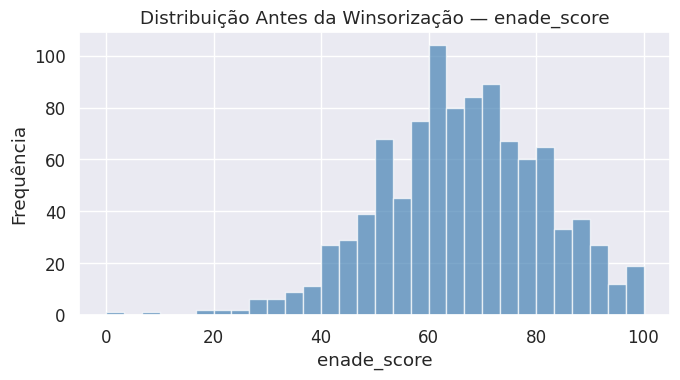

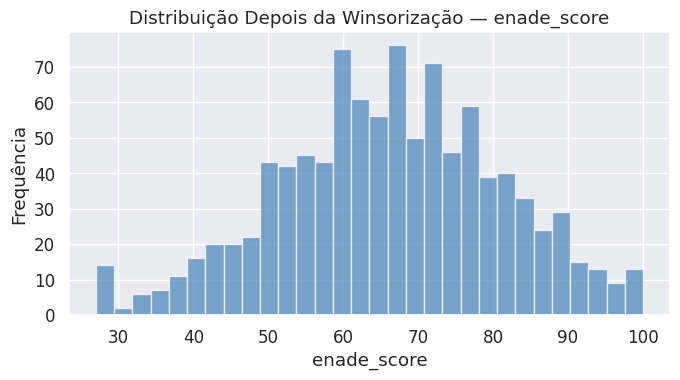

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df["enade_score"], bins=30, alpha=0.7, color="steelblue")
plt.title("Distribuição Antes da Winsorização — enade_score")
plt.xlabel("enade_score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))
plt.hist(df2["enade_score"], bins=30, alpha=0.7, color="steelblue")
plt.title("Distribuição Depois da Winsorização — enade_score")
plt.xlabel("enade_score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

#### Codificando Variáveis Categóricas

In [ ]:
categoricas = list(df2.select_dtypes(include=['object']).columns)

ohe = OneHotEncoder(drop='first', sparse_output=False)

df_ohe = pd.DataFrame(ohe.fit_transform(df2[categoricas]), columns=ohe.get_feature_names_out(categoricas))

df_encoded = pd.concat([df2.drop(categoricas, axis=1), df_ohe], axis=1)

df_encoded


,enade_score,reading_score,writing_score,sex_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,72,74.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,69,90,88.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,90,95,93.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,47,57,44.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,76,78,75.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
996,62,55,55.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
997,59,71,65.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
998,68,78,77.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


#### Normalizando (MinMax Scaler)

In [ ]:
colunas = ['reading_score', 'writing_score']

scaler = MinMaxScaler()

df_encoded[colunas] = scaler.fit_transform(df_encoded[colunas])

df_encoded.head()

,enade_score,reading_score,writing_score,sex_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,0.605634,0.649241,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,69,0.859155,0.838111,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,90,0.929577,0.905565,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,47,0.394366,0.244519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,76,0.690141,0.662732,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


### Separação da varável alvo

In [ ]:
X = df_encoded.drop("enade_score", axis=1)
y = df_encoded["enade_score"]

In [ ]:
X.head()

,reading_score,writing_score,sex_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,0.605634,0.649241,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.859155,0.838111,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.929577,0.905565,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0.394366,0.244519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.690141,0.662732,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


### Modelagem

Divisão de treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X[['reading_score']], y, test_size=0.3, random_state=42)

1. Regressão Simples

In [ ]:
modelo_simples = LinearRegression()

modelo_simples.fit(X_train, y_train)

LinearRegression()

Coeficientes do modelo

In [ ]:
b0 = modelo_simples.intercept_
b1 = modelo_simples.coef_[0]

print(f"b0: {b0}")
print(f"b1: {b1}")

b0: 32.11858994244924
b1: 60.111113906751825


Prever valores no conjunto de teste

In [ ]:
y_pred_simples = modelo_simples.predict(X_test)

Visualização: reta ajustada + pontos reais

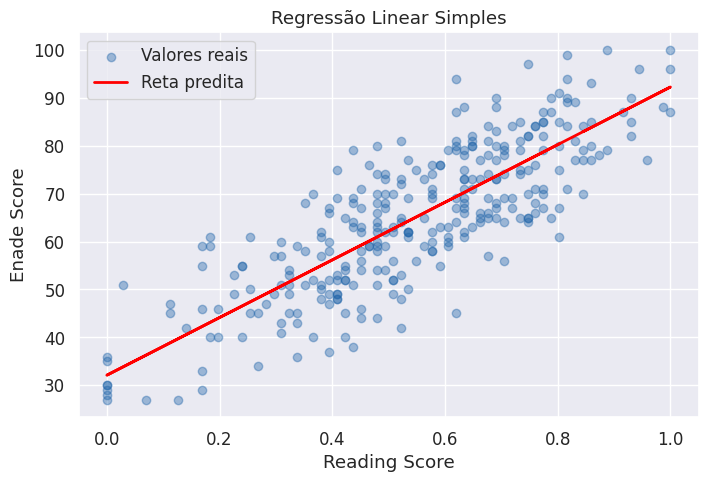

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.4, label="Valores reais", color="#2266aa")
plt.plot(X_test, y_pred_simples, color="red", linewidth=2, label="Reta predita")
plt.xlabel("Reading Score")
plt.ylabel("Enade Score")
plt.title("Regressão Linear Simples")
plt.legend()
plt.show()

Regressão Múltipla

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X_train, y_train)

LinearRegression()

In [ ]:
coeficientes = {'Nome': X.columns,
                'Intercepto': modelo_multiplo.intercept_,
                'Coef angular': modelo_multiplo.coef_}

df_coeficientes = pd.DataFrame(coeficientes).sort_values(by='Coef angular', ascending=False)
df_coeficientes

,Nome,Intercepto,Coef angular
1,writing_score,15.73867,52.495085
0,reading_score,15.73867,17.267813
2,sex_male,15.73867,12.776506
6,race/ethnicity_group E,15.73867,4.534740
12,lunch_standard,15.73867,3.355933
13,test_preparation_course_none,15.73867,2.997000
10,parental_level_of_education_some college,15.73867,1.030664
8,parental_level_of_education_high school,15.73867,0.880667
11,parental_level_of_education_some high school,15.73867,0.713113
3,race/ethnicity_group B,15.73867,0.051380


In [ ]:
y_pred_multiplo = modelo_multiplo.predict(X_test)

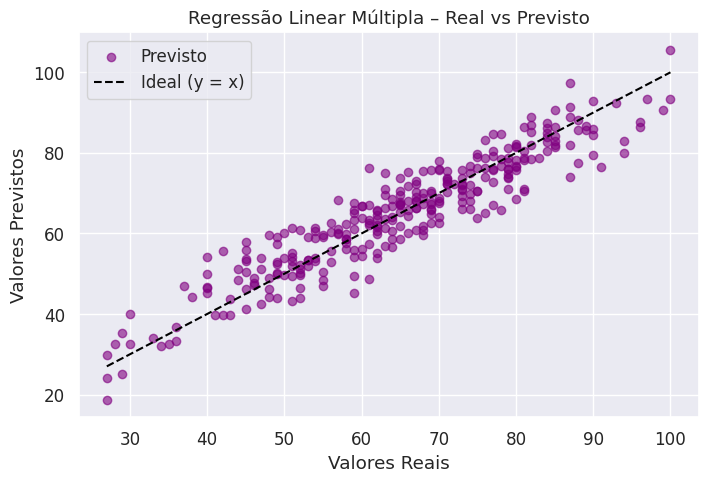

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_multiplo, color='purple', alpha=0.6, label='Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='black', linestyle='--', label='Ideal (y = x)')

plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Regressão Linear Múltipla – Real vs Previsto")
plt.legend()
plt.show()


### Avaliação de Desempenho

In [ ]:
def avaliar_modelo(preds, y_test):
  mae = mean_absolute_error(y_test, preds)
  mse = mean_squared_error(y_test, preds)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, preds)

  print(f"MAE: {mae:.2f}")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"R²: {r2:.2f}")

Regressão Linear Simples

In [ ]:
avaliar_modelo(y_pred_simples, y_test)

MAE: 7.41
MSE: 80.18
RMSE: 8.95
R²: 0.66


Regressão Linear Múltipla

In [ ]:
avaliar_modelo(y_pred_multiplo, y_test)

MAE: 4.40
MSE: 30.78
RMSE: 5.55
R²: 0.87


Análise de Resíduos

Ela é essencial porque permite avaliar se o modelo de regressão:

1. Está capturando bem a relação entre as variáveis

* Se os resíduos parecem “aleatórios”, significa que o modelo não  deixou padrões importantes para trás.

2. Está cometendo erros sistemáticos

* Se os resíduos formam padrões (curvatura, tendência), é sinal de que: a relação não é linear, o modelo está mal especificado, está faltando variável importante, há outliers influenciando.

3. Tem variância constante dos erros

* Isso é chamado de **homocedasticidade**, um dos pilares da regressão linear.

4. Está adequado para uso

* Mesmo com métricas boas, um modelo pode ter comportamento ruim se os resíduos são estruturados.

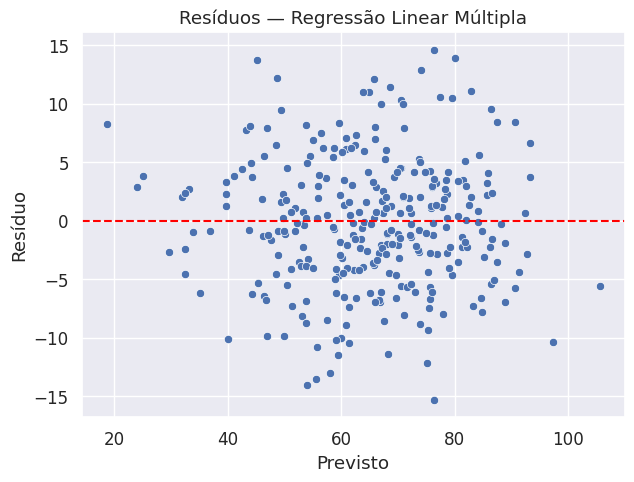

In [ ]:
residuos = y_test - y_pred_multiplo

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_multiplo, y=residuos)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos — Regressão Linear Múltipla")
plt.show()

### Regularização

Regressão Ridge

In [ ]:
ridge = Ridge(alpha=0.01)

ridge.fit(X_train, y_train)

Ridge(alpha=0.01)

In [ ]:
y_ridge = ridge.predict(X_test)

avaliar_modelo(y_ridge, y_test)

MAE: 4.40
MSE: 30.78
RMSE: 5.55
R²: 0.87


Regressão Lasso

In [ ]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

In [ ]:
y_lasso = lasso.predict(X_test)

avaliar_modelo(y_lasso, y_test)

MAE: 4.40
MSE: 30.79
RMSE: 5.55
R²: 0.87


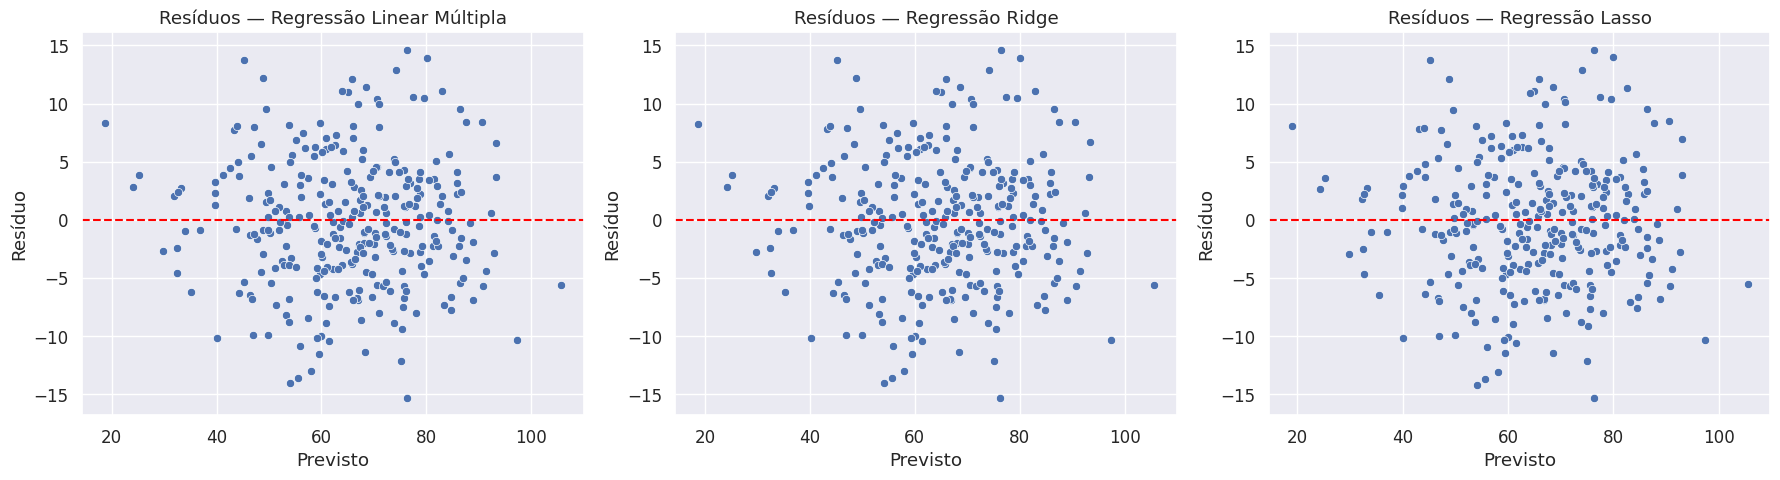

In [ ]:
# Cálculo dos resíduos
residuos_linear = y_test - y_pred_multiplo
residuos_ridge = y_test - y_ridge
residuos_lasso = y_test - y_lasso

# Criando figura com 3 subplots lado a lado
plt.figure(figsize=(18,5))


# --- Regressão Linear Múltipla ---
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_multiplo, y=residuos_linear)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos — Regressão Linear Múltipla")

# --- Regressão Ridge ---
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_ridge, y=residuos_ridge)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos — Regressão Ridge")

# --- Regressão Lasso ---
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_lasso, y=residuos_lasso)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos — Regressão Lasso")

plt.tight_layout()
plt.show()